<a href="https://colab.research.google.com/github/RobBurnap/Bioinformatics-MICR4203-MICR5203/blob/main/notebooks/NB03_BLAST_seeds_extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RobBurnap/Bioinformatics-MICR4203-MICR5203/blob/main/notebooks/NB_BLAST_seeds_extensions.ipynb)

# BLAST — Seeds, extensions, and local alignments
**MICR4203 / MICR5203 · Fall 2026 · Version 1.2**

**Biological question:** How can a search find a similar region inside otherwise different sequences, and when can it miss one?

Save a copy of this notebook in Drive. Run from the top. You will use a dot plot to follow a word hit, extend it one residue at a time, and investigate why some extensions stop. No code writing is required for the core assignment. Allow about **45–60 minutes**.

This lesson follows the supplied **BLAST slide deck**: words and BLOSUM62 (slides 6–8), extension and trimming (10–12), and the dot-plot overview (13). It bridges pairwise alignment and database searching; the cytochrome MSA lesson can follow after candidate sequences have been collected.

### Learning goals
1. Connect a short diagonal in a dot plot to a protein word hit.
2. Explain why similar words need not be identical.
3. Distinguish word threshold **T**, extension drop **X**, and the final alignment score.
4. Predict how changing parameters can recover or miss a local region.
5. Explain what an insertion does to the diagonal.
6. Export labeled PNG figures and use them as evidence in a short report.

**Scope:** This is a transparent, simplified BLAST teaching model. The core uses one-hit triggering and ungapped extension. It computes actual BLOSUM62 scores, but does not reproduce the complete BLAST program, its speed, composition corrections, or significance statistics. The database search is deliberately small. Exact-match dots form the background; scored seeds can include nonidentical residues.

**Canvas submission:** Enter answers and captions in the PDF submission form at the end. Generate and upload **one final PDF**. Keep the notebook and analysis files for your own records.

### Student view
Most Python code is collapsed so you can focus on instructions, controls, and figures. Run each titled cell using its play button. To inspect or edit the Python, use the cell’s **Show code** control or form menu. Code remains part of the notebook.

**First run:** choose **Runtime → Run all**, authorize Drive when prompted, then review the results and complete the answer form. After changing a setting, rerun that cell and the affected analysis cells.


## 1. Tools and output folder
The first cell installs the teaching tools. Colab connects to your course folder in Drive; local Jupyter uses a course folder in the working directory. Every run gets a new output folder. The notebook contains all teaching sequences and functions and needs no data download. Save figures as **300-dpi PNG** (with PDF/SVG copies).


In [1]:
# @title Set up tools and connect Drive
%pip install -q biopython numpy pandas matplotlib ipywidgets reportlab pypdf ipywidgets
from pathlib import Path
from datetime import datetime
import json, hashlib, importlib.metadata, shutil
from IPython.display import display, clear_output
import ipywidgets as widgets
NOTEBOOK_ID = 'NB_BLAST_seeds_extensions'
VERSION = '1.2'
try:
    from google.colab import drive, output
except ImportError:
    COURSE_DIR = Path.cwd() / 'BIOINFO4-5203-F26'
else:
    drive.mount('/content/drive')
    output.enable_custom_widget_manager()
    candidates = [Path('/content/drive/MyDrive/BIOINFO4-5203-F26'),
                  Path('/content/drive/MyDrive/Teaching/BIOINFO4-5203-F26')]
    COURSE_DIR = next((p for p in candidates if p.exists()), candidates[0])
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
OUTPUT_DIR = COURSE_DIR / 'Outputs' / NOTEBOOK_ID / RUN_ID
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FIGURE_FORMATS = ('png','svg','pdf')
figure_paths = []
print('This run saves to:', OUTPUT_DIR)
def export_figure(fig, name):
    for extension in FIGURE_FORMATS:
        path = OUTPUT_DIR / f'{name}.{extension}'
        fig.savefig(path,dpi=300,bbox_inches='tight',facecolor='white')
        if path not in figure_paths: figure_paths.append(path)
    print('Saved:', name+'.png (+ SVG/PDF)')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.6 MB/s eta 0:00:00
Mounted at /content/drive
This run saves to: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/NB_BLAST_seeds_extensions/20260916_023559_930754


## 2. Load the teaching model
Run this long cell once; you do not need to edit it. It defines sequences and reusable calculations so later cells remain short.

**Coordinate convention:** Figures and tables show **1-based residue positions**, with inclusive endpoints. Internal Python slices use 0-based starts and exclusive ends.

**Extension convention:** Each direction starts at the seed score. Stop when **best score so far − current score > X**, measured here in **raw BLOSUM62 score units**. Equality does not stop this model. Keep the earliest best endpoint if scores tie. Left and right extensions run independently; combine them by adding their best scores and subtracting the seed score once. Values of X in this notebook should not be copied directly into BLAST options expressed in bits.


In [2]:
# @title Load the seed-extension teaching model
from dataclasses import dataclass
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align
from Bio.Align import substitution_matrices

MATRIX = substitution_matrices.load('BLOSUM62')
AA = 'ACDEFGHIKLMNPQRSTVWY'
CASES = {
    'slide_gtw': dict(label='Lecture GTW example',
        query='KENFDKARFSGTWYAMAKKDPEG', subject='MKGLDIQKVAGTWYSLAMAASD',
        preferred=(10,10), note='Peptide strings transcribed from slide 10; terminal numbering and punctuation omitted. These are teaching excerpts, not accession-verified full proteins.'),
    'valley': dict(label='Mismatch valley',
        query='EEEEGTWAILMKWWWNQHCFYWWWWWW', subject='PPPPGTWAILMKDDDNQHCFYDDDDDD',
        preferred=(4,4), note='Synthetic: three W/D pairs create a 12-point score valley between matching regions.'),
    'insertion': dict(label='Insertion shifts the diagonal',
        query='EEEEGTWAILMKNQHCFYWWWWWW', subject='PPPPGTWAILMKDDDDNQHCFYDDDDDD',
        preferred=(4,4), note='Synthetic: a four-residue insertion shifts the second matching region by four subject positions.'),
    'weak_seed': dict(label='Conservative substitutions; seed threshold matters',
        query='ILVAILVAILVAILVAILVA', subject='VILAVILAVILAVILAVILA',
        preferred=(0,0), note='Synthetic: conservative residues can accumulate a useful score while no word reaches a stringent threshold.')
}

@dataclass(frozen=True)
class Seed:
    i: int
    j: int
    w: int
    score: float


def validate_protein(sequence):
    if not sequence or not set(sequence) <= set(AA):
        raise ValueError('Use nonempty uppercase sequences containing only the 20 standard amino acids.')


def find_seeds(query, subject, w=3, threshold=11, mode='scored'):
    validate_protein(query); validate_protein(subject)
    if not isinstance(w, int) or w < 1: raise ValueError('Word length must be a positive integer.')
    if mode not in ('scored', 'exact'): raise ValueError('Choose scored or exact.')
    seeds = []
    for i in range(len(query)-w+1):
        for j in range(len(subject)-w+1):
            qword, sword = query[i:i+w], subject[j:j+w]
            score = float(sum(MATRIX[a,b] for a,b in zip(qword,sword)))
            accepted = qword == sword if mode == 'exact' else score >= threshold
            if accepted: seeds.append(Seed(i,j,w,score))
    return seeds


def two_hit_seeds(seeds, window=40):
    # Two non-overlapping words, same diagonal, start separation w..window inclusive.
    return [a for a in seeds if any(a != b and a.i-a.j == b.i-b.j
            and a.w <= abs(a.i-b.i) <= window for b in seeds)]


def extend_side(query, subject, seed, direction='right', xdrop=6):
    if direction not in ('left','right') or xdrop < 0:
        raise ValueError('Direction must be left/right and X-drop must be nonnegative.')
    if seed.i < 0 or seed.j < 0 or seed.i+seed.w > len(query) or seed.j+seed.w > len(subject):
        raise ValueError('Seed is outside the sequences.')
    trace = [dict(step=0, score=seed.score, best_score=seed.score, best_step=0,
                  delta=0., qi=None, sj=None, drop=0., stop=False)]
    score = best = seed.score
    best_step = 0
    limit = min(seed.i, seed.j) if direction=='left' else min(len(query)-seed.i-seed.w, len(subject)-seed.j-seed.w)
    for k in range(1, limit+1):
        qi = seed.i-k if direction=='left' else seed.i+seed.w+k-1
        sj = seed.j-k if direction=='left' else seed.j+seed.w+k-1
        delta = float(MATRIX[query[qi],subject[sj]])
        score += delta
        if score > best:  # Earliest endpoint wins a tie.
            best, best_step = score, k
        drop = best-score
        stop = drop > xdrop  # Explicit strict boundary for this teaching implementation.
        trace.append(dict(step=k, score=score, best_score=best, best_step=best_step,
                          delta=delta, qi=qi, sj=sj, drop=drop, stop=stop))
        if stop: break
    return trace


def extend_seed(query, subject, seed, xdrop=6):
    left = extend_side(query,subject,seed,'left',xdrop)
    right = extend_side(query,subject,seed,'right',xdrop)
    l, r = left[-1]['best_step'], right[-1]['best_step']
    return dict(seed=seed, left=left, right=right,
        q_start=seed.i-l, q_end=seed.i+seed.w+r,
        s_start=seed.j-l, s_end=seed.j+seed.w+r,
        score=left[-1]['best_score']+right[-1]['best_score']-seed.score)


def best_heuristic(query, subject, w=3, threshold=11, xdrop=6, mode='scored', two_hit=False):
    seeds = find_seeds(query,subject,w,threshold,mode)
    triggered = two_hit_seeds(seeds) if two_hit else seeds
    runs = [extend_seed(query,subject,s,xdrop) for s in triggered]
    best = max(runs,key=lambda r:r['score']) if runs else None
    return dict(seed_count=len(seeds), triggered_count=len(triggered),
                extension_pairs=sum(len(r['left'])+len(r['right'])-2 for r in runs), best=best)


def optimal_ungapped(query, subject):
    # Exhaustive local alignment with no gaps: best contiguous interval on any diagonal.
    best = dict(score=0., q_start=0, q_end=0, s_start=0, s_end=0)
    for offset in range(-len(query)+1,len(subject)):
        qi, sj = max(0,-offset), max(0,offset)
        score=0.; begin_q,begin_s=qi,sj
        while qi<len(query) and sj<len(subject):
            score += float(MATRIX[query[qi],subject[sj]])
            if score>best['score']:
                best=dict(score=score,q_start=begin_q,q_end=qi+1,s_start=begin_s,s_end=sj+1)
            if score<=0:
                score=0.; begin_q,begin_s=qi+1,sj+1
            qi+=1; sj+=1
    return best


def local_gapped(query, subject, gap_open=-11, gap_extend=-1):
    aligner=Align.PairwiseAligner()
    aligner.mode='local'; aligner.substitution_matrix=MATRIX
    aligner.open_gap_score=gap_open; aligner.extend_gap_score=gap_extend
    return aligner.align(query,subject)[0]


def match_dots(ax, query, subject):
    xy=[(j+1,i+1) for i,a in enumerate(query) for j,b in enumerate(subject) if a==b]
    if xy: ax.scatter(*zip(*xy),s=12,color='#acb3bc',alpha=.6,label='Exact residue match')
    ax.set_xlim(.5,len(subject)+.5); ax.set_ylim(len(query)+.5,.5)
    ax.set_xlabel('Subject residue position (1-based)'); ax.set_ylabel('Query residue position (1-based)')
    ax.grid(alpha=.12)


def plot_extension(query,subject,seed,xdrop=6,direction='right',step=None):
    trace=extend_side(query,subject,seed,direction,xdrop)
    if step is None: step=len(trace)-1
    step=min(max(int(step),0),len(trace)-1)
    now=trace[step]
    fig=plt.figure(figsize=(13,9),layout='constrained')
    grid=fig.add_gridspec(2,2,height_ratios=[1.1,1])
    dot=fig.add_subplot(grid[0,:]); scoreax=fig.add_subplot(grid[1,0]); alignax=fig.add_subplot(grid[1,1])
    match_dots(dot,query,subject)
    visited=trace[1:step+1]
    if visited:
        dot.plot([v['sj']+1 for v in visited],[v['qi']+1 for v in visited],'-o',color='#737b84',lw=2,ms=4,label='Explored extension')
        kept=[v for v in visited if v['step']<=now['best_step']]
        if kept: dot.plot([v['sj']+1 for v in kept],[v['qi']+1 for v in kept],'-',color='#14835d',lw=5,label='Retained through best endpoint')
        dot.scatter([now['sj']+1],[now['qi']+1],s=90,marker='x',color='#ac3150',zorder=6,label='Current position')
    dot.plot(np.arange(seed.j+1,seed.j+seed.w+1),np.arange(seed.i+1,seed.i+seed.w+1),'-s',color='#c86e12',lw=4,ms=5,label='Seed')
    dot.legend(loc='upper left',bbox_to_anchor=(1.01,1),fontsize=9)
    dot.set_title(f'{direction.capitalize()} extension • step {step} • X-drop = {xdrop:g} raw-score units')
    shown=trace[:step+1]
    scoreax.plot([v['step'] for v in shown],[v['score'] for v in shown],'-o',ms=4,color='#225fa5',label='Current score')
    scoreax.plot([v['step'] for v in shown],[v['best_score'] for v in shown],color='#14835d',label='Best score so far')
    scoreax.plot([v['step'] for v in shown],[v['best_score']-xdrop for v in shown],'--',color='#ac3150',label='Best − X (stop below)')
    scoreax.set_xlim(-.3,max(1,len(trace)-1)+.3)
    values=[v['score'] for v in trace]+[v['best_score']-xdrop for v in trace]
    scoreax.set_ylim(min(values)-3,max(values)+3)
    scoreax.set_xlabel(f'Residues explored {direction}ward from seed'); scoreax.set_ylabel('Raw BLOSUM62 score (includes seed)')
    scoreax.legend(fontsize=9); scoreax.grid(alpha=.15)
    qs=seed.i-step if direction=='left' else seed.i
    qe=seed.i+seed.w if direction=='left' else seed.i+seed.w+step
    ss=seed.j-step if direction=='left' else seed.j
    se=seed.j+seed.w if direction=='left' else seed.j+seed.w+step
    q,s=query[qs:qe],subject[ss:se]
    middle=''.join('|' if a==b else '+' if MATRIX[a,b]>0 else ' ' for a,b in zip(q,s))
    label='X-drop stop; trim to best endpoint' if now['stop'] else 'Sequence boundary reached' if step==len(trace)-1 else 'Extension in progress'
    text=f'Query   {qs+1:>3} {q} {qe}\n            {middle}\nSubject {ss+1:>3} {s} {se}\n\nCurrent score: {now["score"]:g}\nBest score:    {now["best_score"]:g}\nDrop:          {now["drop"]:g}\nRetain {now["best_step"]} added residues {direction} of seed\n\n{label}\n| identical; + positive substitution'
    alignax.axis('off'); alignax.text(0,.96,text,va='top',fontfamily='monospace',fontsize=10,linespacing=1.65)
    return fig


## 3. Revisit the lecture's GTW neighborhood
The score of a word pair is the sum of three substitution scores. The deck uses T=11; words scoring **at least** 11 pass. An exact match is not required.

**Predict before running:** Which of GTW, GSW, ATW, GTY, and GTM will qualify?


In [3]:
# @title Explore the GTW word neighborhood
word_rows=[]
for candidate in ['GTW','GSW','ATW','NTW','GTY','GTM','DAW']:
    terms=[int(MATRIX[a,b]) for a,b in zip('GTW',candidate)]
    word_rows.append({'query_word':'GTW','candidate':candidate,'terms':' + '.join(map(str,terms)),
                      'score':sum(terms),'passes_T11':sum(terms)>=11})
word_table=pd.DataFrame(word_rows)
display(word_table)
word_table.to_csv(OUTPUT_DIR/'word_neighborhood.tsv',sep='\t',index=False)
print('There are L−w+1 overlapping words in a query of length L.')


,query_word,candidate,terms,score,passes_T11
0,GTW,GTW,6 + 5 + 11,22,True
1,GTW,GSW,6 + 1 + 11,18,True
2,GTW,ATW,0 + 5 + 11,16,True
3,GTW,NTW,0 + 5 + 11,16,True
4,GTW,GTY,6 + 5 + 2,13,True
5,GTW,GTM,6 + 5 + -1,10,False
6,GTW,DAW,-1 + 0 + 11,10,False


There are L−w+1 overlapping words in a query of length L.


## 4. Dot plot to seeds
The mismatch-valley example has two matching regions separated by three W/D substitutions. It is synthetic, so we know exactly where we placed the interruption. Background dots indicate **identical residues**, including chance matches away from the main diagonal.

Compare exact 3-letter words with scored 3-letter words. Threshold T applies only in **scored** mode. This exhaustive teaching scan compares every word pair; production BLAST uses efficient lookup/search strategies.


Saved: fig01_dots_and_seeds.png (+ SVG/PDF)


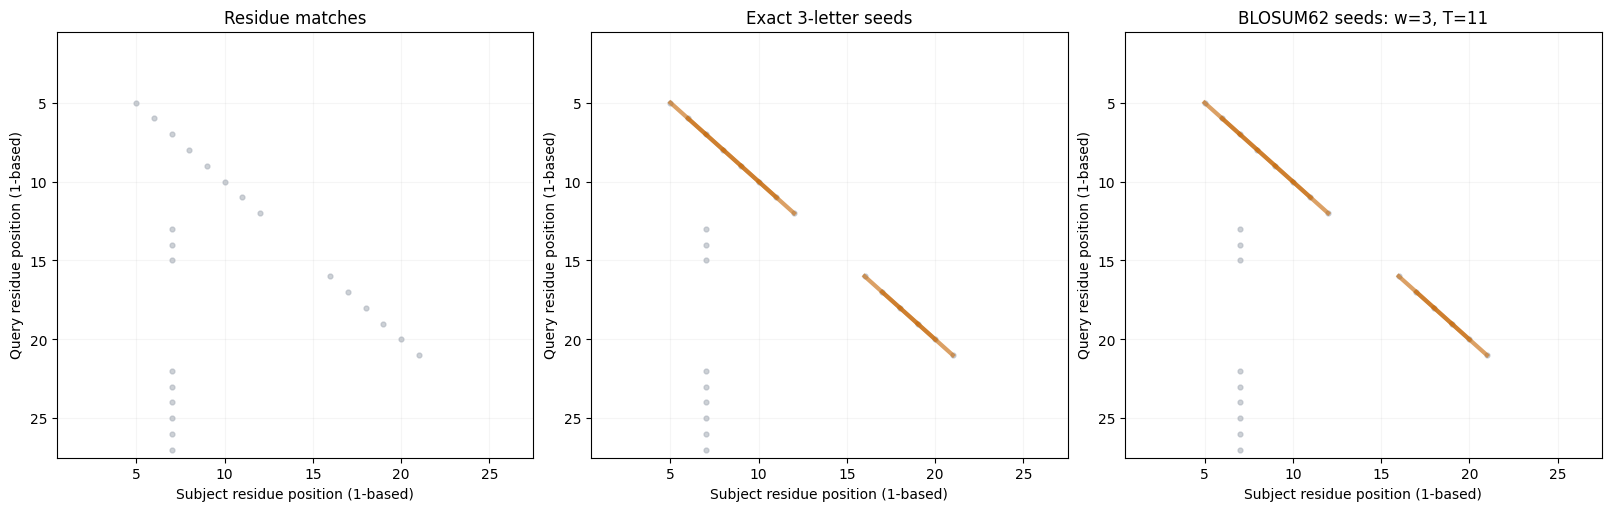

Query  : EEEEGTWAILMKWWWNQHCFYWWWWWW
Subject: PPPPGTWAILMKDDDNQHCFYDDDDDD


In [4]:
# @title Compare dots and seeds
case=CASES['valley']; query,subject=case['query'],case['subject']
fig,axes=plt.subplots(1,3,figsize=(16,5),layout='constrained')
for ax,title,mode in zip(axes,['Residue matches','Exact 3-letter seeds','BLOSUM62 seeds: w=3, T=11'],[None,'exact','scored']):
    match_dots(ax,query,subject)
    if mode:
        for seed in find_seeds(query,subject,3,11,mode):
            ax.plot(range(seed.j+1,seed.j+4),range(seed.i+1,seed.i+4),color='#c86e12',lw=3,alpha=.65)
    ax.set_title(title)
export_figure(fig,'fig01_dots_and_seeds');plt.show();plt.close(fig)
print('Query  :',query);print('Subject:',subject)


## 5. Interactive centerpiece — follow one seed
Start with **Mismatch valley**, w=3, T=11, seed **Q5/S5 (GTW/GTW)**, right extension, X=6. Move the step slider or press **Next residue**. The dot plot, running score, and explored alignment update together.

- **Orange squares:** seed.
- **Gray extension:** positions explored.
- **Green segment:** extension retained through the best score so far.
- **×:** current position.
- **Dashed score line:** best score minus X; stop only below that line.

The alignment displays everything explored, including residues later trimmed away. At the final step, read the retained-length annotation to distinguish the result from the explored span. Then change **X to 16** and repeat. Changing a parameter resets the step to zero. Each direction has its own trace, starting at the seed score.

**If controls do not appear:** run the notebook in an active Colab/Jupyter session. Saved previews do not run Python callbacks. Section 6 provides static figures using the same calculations.


In [5]:
# @title Open the interactive seed-extension display
case_picker=widgets.Dropdown(options=[(c['label'],k) for k,c in CASES.items()],value='valley',description='Example:',layout=widgets.Layout(width='95%'))
mode_picker=widgets.Dropdown(options=[('BLOSUM62 words','scored'),('Exact words','exact')],value='scored',description='Seed mode:')
w_picker=widgets.Dropdown(options=[2,3,4],value=3,description='Word size:')
t_picker=widgets.IntSlider(min=0,max=30,value=11,description='Threshold T:',continuous_update=False)
x_picker=widgets.Dropdown(options=[0,3,6,10,12,16,24],value=6,description='X-drop:')
seed_picker=widgets.Dropdown(description='Seed:',layout=widgets.Layout(width='95%'))
direction_picker=widgets.Dropdown(options=['right','left'],value='right',description='Direction:')
step_picker=widgets.IntSlider(min=0,max=1,value=0,description='Step:',continuous_update=False,layout=widgets.Layout(width='95%'))
next_button=widgets.Button(description='Next residue')
finish_button=widgets.Button(description='Run to stop')
save_button=widgets.Button(description='Save current figure')
view=widgets.Output(); message=widgets.Output()
ui_state={'busy':False,'seeds':[],'trace':[]}
def current_values():
    c=CASES[case_picker.value]
    seed=ui_state['seeds'][seed_picker.value] if seed_picker.value is not None else None
    return c,seed

def draw_current(change=None):
    if ui_state['busy']:return
    with view:
        clear_output(wait=True)
        c,seed=current_values()
        if seed is None:
            print('No seeds pass these settings. Lower T, shorten the word, or change the example. No extension is attempted.')
            return
        fig=plot_extension(c['query'],c['subject'],seed,x_picker.value,direction_picker.value,step_picker.value)
        plt.show();plt.close(fig)

def update_trace(change=None):
    if ui_state['busy']:return
    ui_state['busy']=True
    c,seed=current_values()
    trace=extend_side(c['query'],c['subject'],seed,direction_picker.value,x_picker.value) if seed else []
    ui_state['trace']=trace
    step_picker.value=0;step_picker.max=max(0,len(trace)-1)
    for control in [step_picker,next_button,finish_button,save_button]:control.disabled=seed is None
    ui_state['busy']=False
    draw_current()

def update_seeds(change=None):
    if ui_state['busy']:return
    ui_state['busy']=True
    c=CASES[case_picker.value]
    seeds=find_seeds(c['query'],c['subject'],w_picker.value,t_picker.value,mode_picker.value)
    ui_state['seeds']=seeds
    seed_picker.options=[(f'Q{s.i+1}/S{s.j+1}: {c["query"][s.i:s.i+s.w]}/{c["subject"][s.j:s.j+s.w]} (score {s.score:g})',k) for k,s in enumerate(seeds)]
    preferred=next((k for k,s in enumerate(seeds) if (s.i,s.j)==tuple(c['preferred'])),0)
    seed_picker.value=preferred if seeds else None
    t_picker.disabled=mode_picker.value=='exact'
    ui_state['busy']=False
    update_trace()

def save_current(button):
    c,seed=current_values()
    if seed is None:return
    fig=plot_extension(c['query'],c['subject'],seed,x_picker.value,direction_picker.value,step_picker.value)
    stem=f'interactive_{case_picker.value}_w{seed.w}_Q{seed.i+1}_S{seed.j+1}_X{x_picker.value}_{direction_picker.value}_step{step_picker.value}'
    with message:
        clear_output(wait=True);export_figure(fig,stem)
    plt.close(fig)
    (OUTPUT_DIR/(stem+'.json')).write_text(json.dumps(dict(example=case_picker.value,word_size=seed.w,threshold=t_picker.value,mode=mode_picker.value,seed_q=seed.i+1,seed_s=seed.j+1,xdrop=x_picker.value,direction=direction_picker.value,step=step_picker.value),indent=2))
for control in [case_picker,mode_picker,w_picker,t_picker]:control.observe(update_seeds,names='value')
for control in [seed_picker,x_picker,direction_picker]:control.observe(update_trace,names='value')
step_picker.observe(draw_current,names='value')
next_button.on_click(lambda b:setattr(step_picker,'value',min(step_picker.max,step_picker.value+1)))
finish_button.on_click(lambda b:setattr(step_picker,'value',step_picker.max))
save_button.on_click(save_current)
display(widgets.VBox([case_picker,widgets.HBox([mode_picker,w_picker]),t_picker,
                     seed_picker,widgets.HBox([direction_picker,x_picker]),step_picker,
                     widgets.HBox([next_button,finish_button,save_button]),message,view]))
update_seeds()


## 6. Experiment A — cross the mismatch valley
These static exports also work if the interactive display is unavailable. They follow the **same selected seed**, which is important: an all-seed search might enter the second region from a different seed even when this seed stops early.

**Predict:** Does X change the substitution scores? Does the algorithm retain all the residues it explores?


Saved: fig02_valley_X6.png (+ SVG/PDF)


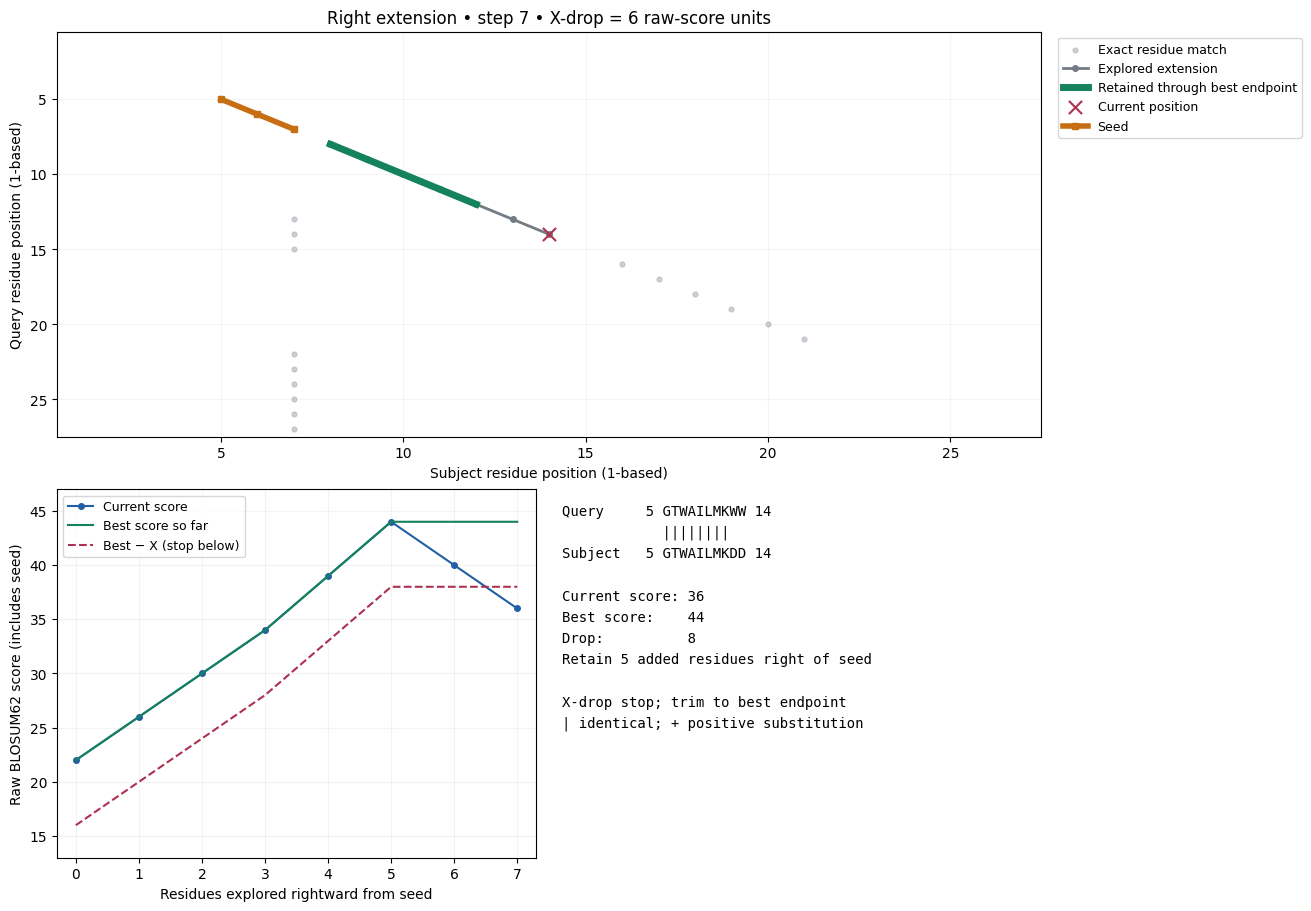

Saved: fig02_valley_X16.png (+ SVG/PDF)


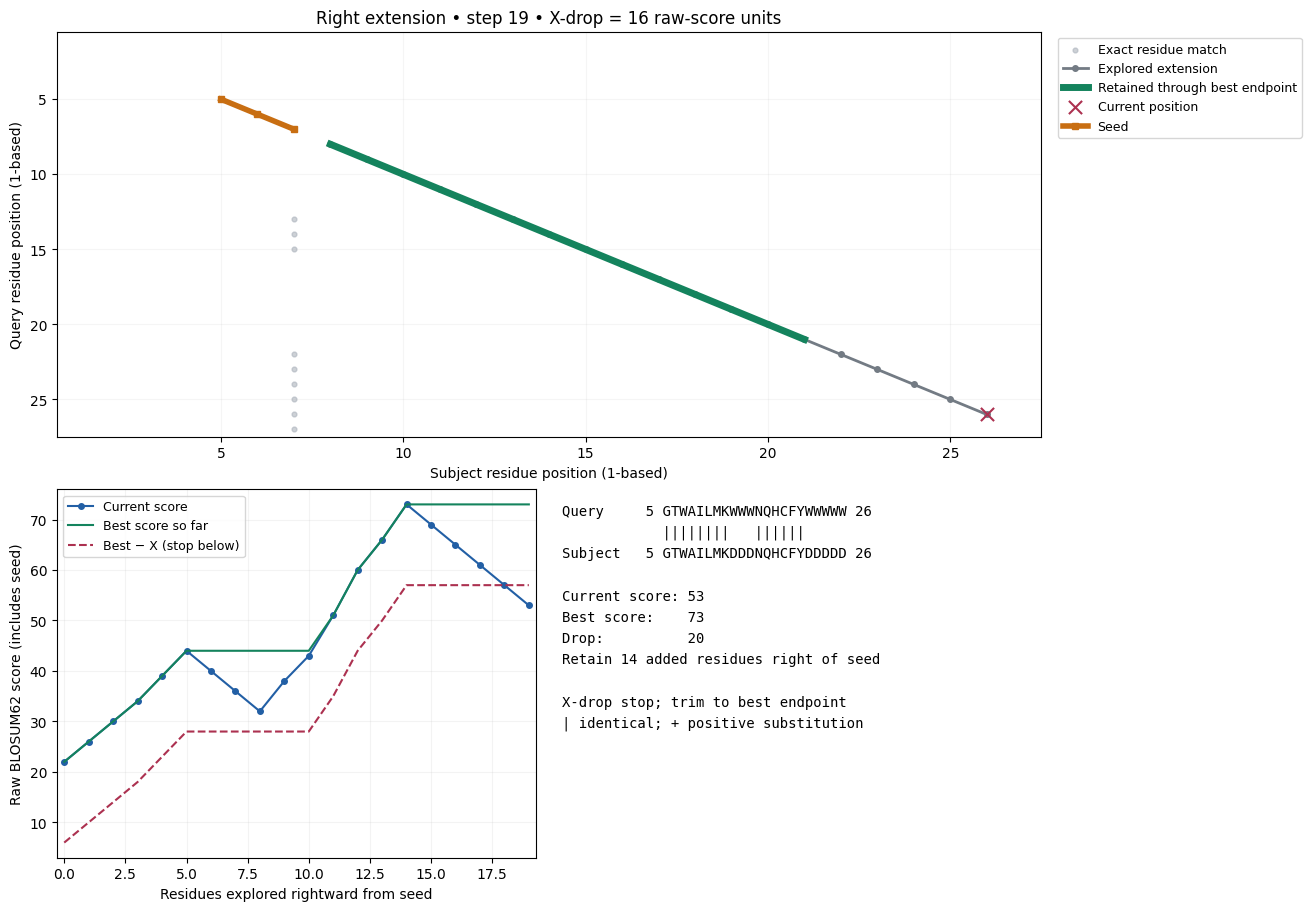

,xdrop,combined_retained_score,query_start,query_end,right_explored,right_retained,stop_drop
0,6,44.0,5,12,7,5,8.0
1,16,73.0,5,21,19,14,20.0


The three W/D pairs lose 12 raw-score points in total.


In [6]:
# @title Compare X-drop 6 and 16
valley=CASES['valley'];q,s=valley['query'],valley['subject']
central=next(seed for seed in find_seeds(q,s) if (seed.i,seed.j)==(4,4))
valley_rows=[]
for X in [6,16]:
    result=extend_seed(q,s,central,X)
    right=result['right'][-1]
    valley_rows.append(dict(xdrop=X,combined_retained_score=result['score'],
                           query_start=result['q_start']+1,query_end=result['q_end'],
                           right_explored=right['step'],right_retained=right['best_step'],
                           stop_drop=right['drop']))
    pd.DataFrame(result['right']).to_csv(OUTPUT_DIR/f'valley_right_trace_X{X}.tsv',sep='\t',index=False)
    fig=plot_extension(q,s,central,X,'right')
    export_figure(fig,f'fig02_valley_X{X}');plt.show();plt.close(fig)
valley_table=pd.DataFrame(valley_rows)
display(valley_table)
valley_table.to_csv(OUTPUT_DIR/'valley_comparison.tsv',sep='\t',index=False)
print('The three W/D pairs lose 12 raw-score points in total.')


## 7. Experiment B — a good region with no acceptable seed
A high local-alignment score does not guarantee that a heuristic search starts there. For this synthetic conservative-substitution example, compare T=6 with T=18, keeping w=3.

The benchmark examines every possible ungapped local segment. Because it uses the **same BLOSUM62 scores and no gaps**, its score is directly comparable to the best retained heuristic score. A missing hit is shown as NaN, not an alignment with score zero.


,threshold,seeds,best_score,exhaustive_score
0,6,127,50.0,50.0
1,8,77,50.0,50.0
2,11,0,NaN,50.0
3,18,0,NaN,50.0


Saved: fig03_threshold_missed_region.png (+ SVG/PDF)


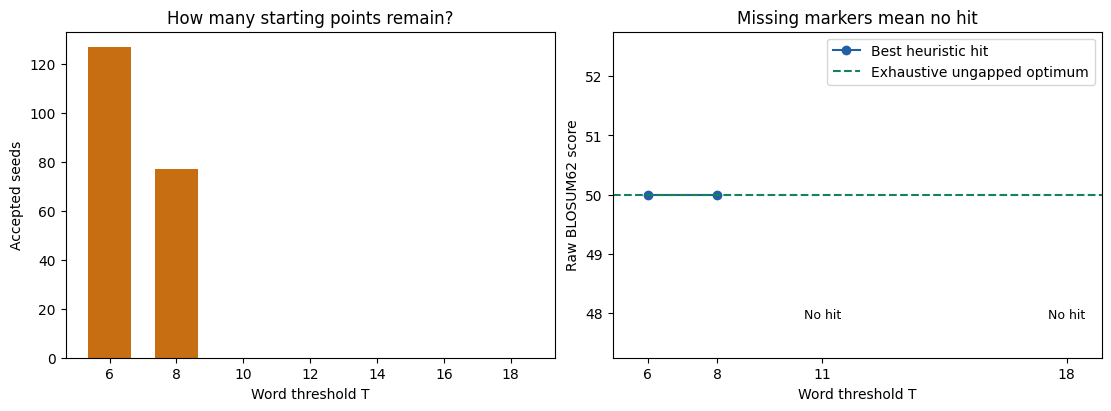

In [7]:
# @title Explore missed seeds and threshold effects
c=CASES['weak_seed'];q,s=c['query'],c['subject']
benchmark=optimal_ungapped(q,s)
threshold_rows=[]
for T in [6,8,11,18]:
    result=best_heuristic(q,s,threshold=T,xdrop=6)
    threshold_rows.append(dict(threshold=T,seeds=result['seed_count'],
                               best_score=result['best']['score'] if result['best'] else np.nan,
                               exhaustive_score=benchmark['score']))
threshold_table=pd.DataFrame(threshold_rows);display(threshold_table)
fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
axes[0].bar(threshold_table.threshold,threshold_table.seeds,width=1.3,color='#c86e12')
axes[0].set(xlabel='Word threshold T',ylabel='Accepted seeds',title='How many starting points remain?')
axes[1].plot(threshold_table.threshold,threshold_table.best_score,'o-',label='Best heuristic hit',color='#225fa5')
axes[1].axhline(benchmark['score'],ls='--',color='#14835d',label='Exhaustive ungapped optimum')
axes[1].set(xlabel='Word threshold T',ylabel='Raw BLOSUM62 score',title='Missing markers mean no hit')
axes[1].set_xticks(threshold_table.threshold)
axes[1].set_xlim(threshold_table.threshold.min()-1, threshold_table.threshold.max()+1)
for missing_T in threshold_table.loc[threshold_table.best_score.isna(), 'threshold']:
    axes[1].text(missing_T, .12, 'No hit', transform=axes[1].get_xaxis_transform(), ha='center', fontsize=9)
axes[1].legend();export_figure(fig,'fig03_threshold_missed_region');plt.show();plt.close(fig)
threshold_table.to_csv(OUTPUT_DIR/'threshold_experiment.tsv',sep='\t',index=False)


## 8. Experiment C — an insertion shifts the diagonal
The subject has an inserted **DDDD** before NQHCFY. An ungapped extension follows one fixed diagonal. A gapped alignment can follow matching residues on both sides of an insertion.

Here Biopython computes an **optimal gapped local alignment**, not a BLAST gapped extension. The gap cost is −11 for the first gap position and −1 for each additional position: a length-four gap costs −14 in this implementation. The green path includes horizontal/vertical moves for gaps. Raw scores from gapped and ungapped alignments answer different optimization questions.


target            4 GTWAILMK----NQHCFY 18
                  0 ||||||||----|||||| 18
query             4 GTWAILMKDDDDNQHCFY 22

Optimal gapped score: 71.0
Optimal ungapped score: 45.0
Saved: fig04_insertion_and_gapped_path.png (+ SVG/PDF)


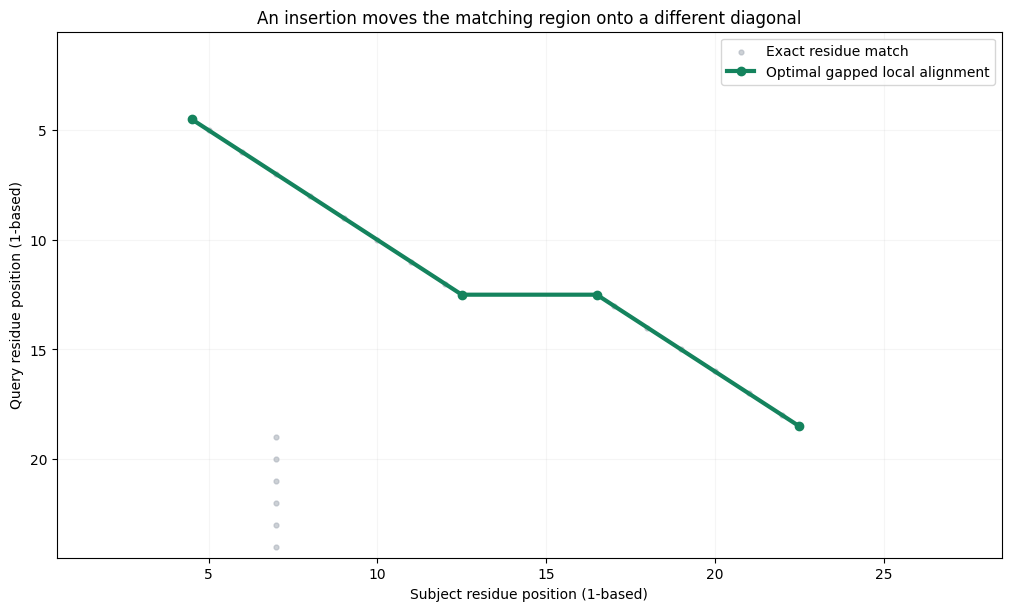

138

In [8]:
# @title Display the insertion and gapped path
c=CASES['insertion'];q,s=c['query'],c['subject']
gapped=local_gapped(q,s)
print(gapped)
print('Optimal gapped score:',gapped.score)
print('Optimal ungapped score:',optimal_ungapped(q,s)['score'])
fig,ax=plt.subplots(figsize=(10,6),layout='constrained')
match_dots(ax,q,s)
# Alignment coordinates are boundaries, so add 0.5 to place the path between residue centers.
coords=gapped.coordinates
ax.plot(coords[1]+.5,coords[0]+.5,'-o',lw=3,color='#14835d',label='Optimal gapped local alignment')
ax.set_title('An insertion moves the matching region onto a different diagonal')
ax.legend(loc='best');export_figure(fig,'fig04_insertion_and_gapped_path');plt.show();plt.close(fig)
(OUTPUT_DIR/'insertion_gapped_alignment.txt').write_text(str(gapped)+'\nScore: '+str(gapped.score))


## 9. Search a small, reproducible database
Search one query against synthetic variants and shuffled controls. Database records remain separate; seeds never cross a record boundary. All controls use a fixed random seed.

Observe the highest scoring **local segment**, its identity, and query coverage. Identity here counts matching residue pairs in an ungapped retained segment. A high identity over a very short region differs from high coverage. A shuffled control can still contain a chance match.

**No E-values are computed by this model.** These scores cannot establish statistical significance or biological homology. Label designed variants as synthetic variants, not discovered homologs.


,subject,seed_count,extension_pairs,score,query_start,query_end,subject_start,subject_end,identity,query_coverage
1,synthetic_copy,91,1658,204.0,1,27,1,27,1.000,1.000
0,synthetic_valley_variant,10,230,73.0,5,21,5,21,0.824,0.630
7,shuffled_control_5,64,1099,67.0,14,27,4,17,0.500,0.519
6,shuffled_control_4,70,1060,66.0,14,27,2,15,0.500,0.519
4,shuffled_control_2,75,992,61.0,15,26,1,12,0.583,0.444
5,shuffled_control_3,50,516,59.0,7,27,2,22,0.333,0.778
3,shuffled_control_1,73,1094,44.0,10,27,5,22,0.278,0.667
2,synthetic_insertion_variant,10,202,44.0,5,12,5,12,1.000,0.296


Saved: fig05_mini_database_hits.png (+ SVG/PDF)


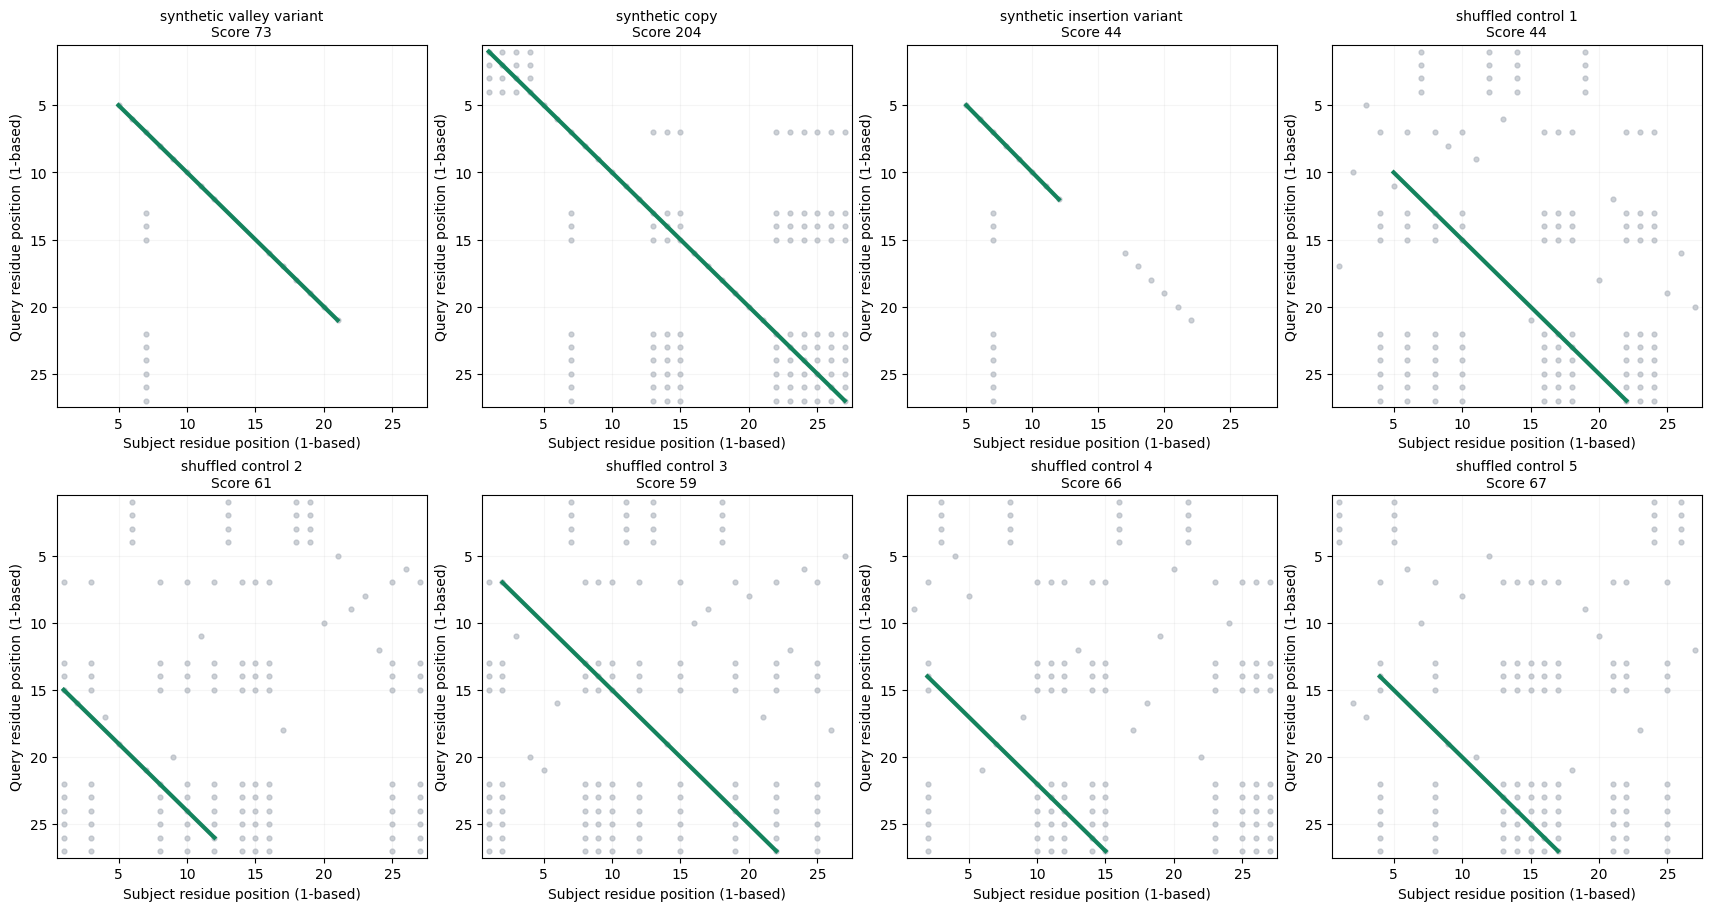

45

In [9]:
# @title Search the small teaching database
rng=np.random.default_rng(4203)
database_query=CASES['valley']['query']
mini_database=[('synthetic_valley_variant',CASES['valley']['subject']),
               ('synthetic_copy',database_query),
               ('synthetic_insertion_variant',CASES['insertion']['subject'])]
mini_database += [(f'shuffled_control_{i+1}',''.join(rng.permutation(list(database_query)))) for i in range(5)]
database_rows=[]
for name,sequence in mini_database:
    result=best_heuristic(database_query,sequence,threshold=11,xdrop=16)
    best=result['best']
    row=dict(subject=name,seed_count=result['seed_count'],extension_pairs=result['extension_pairs'],
             score=np.nan,query_start=np.nan,query_end=np.nan,subject_start=np.nan,subject_end=np.nan,identity=np.nan,query_coverage=np.nan)
    if best:
        qa=database_query[best['q_start']:best['q_end']];sa=sequence[best['s_start']:best['s_end']]
        row.update(score=best['score'],query_start=best['q_start']+1,query_end=best['q_end'],
                   subject_start=best['s_start']+1,subject_end=best['s_end'],
                   identity=sum(a==b for a,b in zip(qa,sa))/len(qa),query_coverage=len(qa)/len(database_query))
    database_rows.append(row)
database_table=pd.DataFrame(database_rows).sort_values('score',ascending=False)
display(database_table.round(3))
fig,axes=plt.subplots(2,4,figsize=(17,9),layout='constrained')
for ax,(name,sequence),row in zip(axes.flat,mini_database,database_rows):
    match_dots(ax,database_query,sequence)
    if not np.isnan(row['score']):
        ax.plot([row['subject_start'],row['subject_end']],[row['query_start'],row['query_end']],lw=3,color='#14835d')
    ax.set_title(name.replace('_',' ')+'\n'+('No hit' if np.isnan(row['score']) else f'Score {row["score"]:g}'),fontsize=10)
export_figure(fig,'fig05_mini_database_hits');plt.show();plt.close(fig)
database_table.to_csv(OUTPUT_DIR/'mini_database_results.tsv',sep='\t',index=False)
(OUTPUT_DIR/'mini_database.fasta').write_text(''.join(f'>{name}\n{seq}\n' for name,seq in mini_database))
(OUTPUT_DIR/'query.fasta').write_text('>synthetic_query\n'+database_query+'\n')


## 10. Parameter investigation
Vary w, T, and X. Record the number of seeds, the number of extension residue pairs visited, and whether the best hit reaches the exhaustive ungapped optimum.

The work counter includes redundant extensions and excludes word-scanning cost. It illustrates work done by **this model**, not production BLAST speed. For larger words, a fixed raw word threshold is not a like-for-like sensitivity setting: more residue scores are summed. Word length and threshold must be interpreted together.


In [10]:
# @title Compare parameter settings
parameter_rows=[]
c=CASES['valley'];q,s=c['query'],c['subject'];optimum=optimal_ungapped(q,s)['score']
for w in [2,3,4]:
    for T in [6,11,18]:
        for X in [6,16]:
            result=best_heuristic(q,s,w,T,X)
            score=result['best']['score'] if result['best'] else np.nan
            parameter_rows.append(dict(word_length=w,threshold=T,xdrop=X,seeds=result['seed_count'],
                                       extension_pairs=result['extension_pairs'],best_score=score,
                                       exhaustive_score=optimum,reaches_optimum=bool(np.isclose(score,optimum))))
parameter_table=pd.DataFrame(parameter_rows);display(parameter_table)
parameter_table.to_csv(OUTPUT_DIR/'parameter_sweep.tsv',sep='\t',index=False)


,word_length,threshold,xdrop,seeds,extension_pairs,best_score,exhaustive_score,reaches_optimum
0,2,6,6,29,218,44.0,73.0,False
1,2,6,16,29,449,73.0,73.0,True
2,2,11,6,8,76,44.0,73.0,False
3,2,11,16,8,192,73.0,73.0,True
4,2,18,6,0,0,NaN,73.0,False
5,2,18,16,0,0,NaN,73.0,False
6,3,6,6,42,258,44.0,73.0,False
7,3,6,16,42,516,73.0,73.0,True
8,3,11,6,10,94,44.0,73.0,False
9,3,11,16,10,230,73.0,73.0,True


## 11. MICR5203 extension — two hits on one diagonal
Classic two-hit triggering requires two nearby, non-overlapping word hits on the **same diagonal**. Our educational switch uses a maximum start separation of 40 residues and allows extension from every qualifying seed; it does not reproduce production BLAST's bookkeeping and duplicate suppression.

Compare the number of accepted seeds with the number that trigger extension. Explain why proximity alone is insufficient. What useful region could be missed if only one seed exists?


In [11]:
# @title Compare one-hit and two-hit triggering
two_hit_rows=[]
for name,sequence in mini_database:
    for two_hit in [False,True]:
        result=best_heuristic(database_query,sequence,threshold=11,xdrop=16,two_hit=two_hit)
        two_hit_rows.append(dict(subject=name,trigger='two-hit' if two_hit else 'one-hit',
                                 accepted_seeds=result['seed_count'],triggered_seeds=result['triggered_count'],
                                 extension_pairs=result['extension_pairs'],
                                 score=result['best']['score'] if result['best'] else np.nan))
two_hit_table=pd.DataFrame(two_hit_rows);display(two_hit_table)
two_hit_table.to_csv(OUTPUT_DIR/'two_hit_comparison.tsv',sep='\t',index=False)


,subject,trigger,accepted_seeds,triggered_seeds,extension_pairs,score
0,synthetic_valley_variant,one-hit,10,10,230,73.0
1,synthetic_valley_variant,two-hit,10,10,230,73.0
2,synthetic_copy,one-hit,91,91,1658,204.0
3,synthetic_copy,two-hit,91,45,1056,204.0
4,synthetic_insertion_variant,one-hit,10,10,202,44.0
5,synthetic_insertion_variant,two-hit,10,8,164,44.0
6,shuffled_control_1,one-hit,73,73,1094,44.0
7,shuffled_control_1,two-hit,73,35,615,44.0
8,shuffled_control_2,one-hit,75,75,992,61.0
9,shuffled_control_2,two-hit,75,44,649,61.0


## 12. Optional — compare with real BLAST+
The core assignment does not depend on BLAST installation or a remote search queue. If your instructor wants this comparison, set `RUN_REAL_BLAST = True` after installing BLAST+ in Colab using the commented commands below. The search uses the local synthetic database and sends no sequences to a web service.

For these short teaching peptides, we explicitly choose standard `blastp`, BLOSUM62, w=3, gap costs 11/1, a permissive reporting E-value of 1000, and turn off SEG and composition-based score adjustments for transparency. These settings are **not a recommendation for biological searches**. Real BLAST's scoring corrections, seeding, gap handling, statistical calculations, and filtering can differ from the toy model. Its reported E-values on this tiny synthetic database are for discussion, not biological claims.

Compare coordinates, percent identity, query coverage, bit score, and E-value. The E-value is an expected number of chance alignments at least as good in that search space; it is not the probability a particular hit is false.


In [12]:
# @title Optional: install and run real BLAST+
# OPTIONAL Colab installation:
# !apt-get -qq update
# !apt-get -qq install -y ncbi-blast+
RUN_REAL_BLAST = False
if RUN_REAL_BLAST:
    import subprocess
    if not shutil.which('blastp') or not shutil.which('makeblastdb'):
        raise RuntimeError('Install NCBI BLAST+ first, then rerun this optional cell.')
    db_prefix=OUTPUT_DIR/'blast_database'
    commands=[['makeblastdb','-in',str(OUTPUT_DIR/'mini_database.fasta'),'-dbtype','prot','-out',str(db_prefix)],
              ['blastp','-task','blastp','-query',str(OUTPUT_DIR/'query.fasta'),'-db',str(db_prefix),
               '-matrix','BLOSUM62','-word_size','3','-gapopen','11','-gapextend','1',
               '-seg','no','-comp_based_stats','0','-evalue','1000','-max_target_seqs','100',
               '-outfmt','6 qseqid sseqid pident length qstart qend sstart send bitscore evalue qcovhsp',
               '-out',str(OUTPUT_DIR/'real_blast_results.tsv')]]
    logs=[]
    for command in commands:
        result=subprocess.run(command,capture_output=True,text=True,check=True)
        logs.append({'command':command,'stdout':result.stdout,'stderr':result.stderr})
    (OUTPUT_DIR/'real_blast_commands.json').write_text(json.dumps(logs,indent=2))
    (OUTPUT_DIR/'real_blast_version.txt').write_text(subprocess.run(['blastp','-version'],capture_output=True,text=True,check=True).stdout)
    path=OUTPUT_DIR/'real_blast_results.tsv'
    if path.stat().st_size:
        display(pd.read_csv(path,sep='\t',header=None,names=['query','subject','percent_identity','alignment_length','qstart','qend','sstart','send','bitscore','evalue','query_coverage_percent']))
    else: print('No real BLAST hits met the selected reporting settings.')
else:
    print('Optional real BLAST comparison skipped. Core assignment is complete.')


Optional real BLAST comparison skipped. Core assignment is complete.


## Report assignment: one PDF for Canvas

Answer the numbered questions in the form at the end of this notebook. Figures F1-F6 are selected automatically from this run; write a caption for each. Your PDF includes the questions, answers, figures, captions, and run information.

**Q1: Protein words (5 points).** Why does GSW qualify as a seed for GTW at T=11? Show all three substitution scores.

**Q2: Extension at X=6 (10 points).** In the mismatch-valley example, identify seed Q5/S5 and its word. At X=6, how many residues are explored to the right, how many are retained, and what is the retained score? Cite F2.

**Q3: Extension at X=16 (10 points).** Repeat the comparison at X=16 using F3. Explain how unchanged sequences yield a different recovered segment. Distinguish the selected-seed result from an all-seed search.

**Q4: Stopping rule (10 points).** Does this model stop at the first mismatch, when the score becomes negative, or when it falls sufficiently below its best score? Cite evidence from the trace or F2/F3.

**Q5: Boundary and ties (5 points).** What happens when the drop equals X exactly in this implementation? Which endpoint is retained if the same best score occurs twice?

**Q6: Insertion (10 points).** Using F4, identify the sequence with extra residues and how many. Explain the shifted diagonal and how the gapped path connects the matching regions.

**Q7: Missing seed (10 points).** For the conservative-substitution example at T=18, compare the heuristic result with the exhaustive ungapped optimum using F5. Did seeding or extension fail?

**Q8: Database evidence (10 points).** Using F6 and the results table, compare one synthetic variant with one shuffled control in score, identity, and query coverage. Why do those values alone not establish homology?

**Q9: Parameter effects (5 points).** Choose two rows of the parameter sweep and give their w, T, and X values. Explain the changes in work counter and result, and why this does not measure production BLAST runtime.

**Q10: Model limitations (10 points).** Give two differences between this teaching model and real BLAST. Explain why raw scores are not E-values.

**Rubric:** Question responses total 85 points; figure evidence and captions 10 points; complete, identifiable PDF with reproducibility information 5 points. Extensions are included only if assigned; the instructor should announce any changed weighting.

**Submit the generated final PDF only.** Your notebook, PNGs, and analysis ZIP stay in Drive unless separately requested.


## 14. Save the analysis archive (for your records)
Run this cell **after** your interactive saves and optional analyses. It bundles this run's figures, trace tables, sequences, parameters, and any real BLAST outputs. Keep the notebook itself for revisions. Rerun this cell if you add more figures.


In [13]:
# @title Save analysis tables and run information
case_records={k:{'label':c['label'],'query':c['query'],'subject':c['subject'],'note':c['note']} for k,c in CASES.items()}
(OUTPUT_DIR/'teaching_examples.json').write_text(json.dumps(case_records,indent=2))
parameters=dict(notebook_id=NOTEBOOK_ID,version=VERSION,run_id=RUN_ID,matrix='BLOSUM62',
                teaching_stop_rule='best - current > X; raw-score units',tie_rule='earliest best endpoint',
                coordinate_reporting='1-based inclusive; internal Python slices 0-based half-open',
                core_trigger='one-hit',database_parameters={'w':3,'T':11,'X':16},
                random_seed=4203,gapped_cost='11 + (length - 1) * 1',
                two_hit_window=40,real_blast_requested=RUN_REAL_BLAST,
                examples_sha256=hashlib.sha256(json.dumps(case_records,sort_keys=True).encode()).hexdigest(),
                packages={name:importlib.metadata.version(name) for name in ['biopython','numpy','pandas','matplotlib','ipywidgets']})
(OUTPUT_DIR/'run_parameters.json').write_text(json.dumps(parameters,indent=2))
assert len(figure_paths)>=18 and all(p.exists() and p.stat().st_size>0 for p in figure_paths)
pd.DataFrame([{'file':p.name,'bytes':p.stat().st_size} for p in sorted(OUTPUT_DIR.iterdir()) if p.is_file()]).to_csv(OUTPUT_DIR/'file_manifest.tsv',sep='\t',index=False)
archive=shutil.make_archive(str(OUTPUT_DIR.parent/(RUN_ID+'_report_bundle')),'zip',OUTPUT_DIR)
print('Report bundle:',archive)
for p in sorted(OUTPUT_DIR.glob('*.png')):print(' •',p.name)
# Optional Colab download:
# from google.colab import files
# files.download(archive)


Report bundle: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/NB_BLAST_seeds_extensions/20260916_023559_930754_report_bundle.zip
 • fig01_dots_and_seeds.png
 • fig02_valley_X16.png
 • fig02_valley_X6.png
 • fig03_threshold_missed_region.png
 • fig04_insertion_and_gapped_path.png
 • fig05_mini_database_hits.png


## Sources and exit ticket
- Course source: supplied **BLAST.pptx**, slides 6–13. Only the slide-10 peptide strings are transcribed; other teaching sequences are explicitly synthetic.
- [NCBI: BLAST algorithm and command options](https://www.ncbi.nlm.nih.gov/books/NBK279684/)
- [NCBI: local extension overview](https://www.ncbi.nlm.nih.gov/books/NBK1734/)
- [NCBI: E-value interpretation](https://www.nlm.nih.gov/ncbi/workshops/2023-08_BLAST_evol/e_value.html)
- [Biopython: pairwise alignment](https://biopython.org/docs/latest/Tutorial/chapter_pairwise.html)

**Exit ticket:** A promising local region can be missed before extension because ______. An extension can recover after a mismatch because ______.


## Final step: answers and a submission PDF

1. Run the helper and form cells below. Type your name, course/section, answers, and figure captions. Answers save to the course folder when you leave a field or click **Save answers**.
2. Use **Preview draft PDF** to inspect layout while working. It is clearly labeled DRAFT.
3. Complete all required fields, then click **Generate submission PDF**. Missing answers, captions, or figures are listed rather than silently omitted.
4. Click **Download final PDF**, open it, check every page, and upload that **one PDF** in Canvas. Complete the Canvas submission confirmation.

The report generator uses its own page layout: answers flow across pages, and each figure starts on a separate landscape page with its caption below. Your saved answers remain editable in the notebook. If you revise them, generate and upload a new PDF. After rerunning the analysis, review restored answers against the new results.

The PDF contains fixed, searchable text. Students enter answers here rather than relying on PDF viewer form fields. Keep your notebook and Drive folder as your working copy.


In [14]:
# @title Prepare the PDF submission tools
REPORT_TITLE = 'BLAST - Seeds, extensions, and local alignments'
REPORT_QUESTIONS = [{'id': 'Q1', 'title': 'Protein words', 'points': 5, 'prompt': 'Why does GSW qualify as a seed for GTW at T=11? Show all three substitution scores.'}, {'id': 'Q2', 'title': 'Extension at X=6', 'points': 10, 'prompt': 'In the mismatch-valley example, identify seed Q5/S5 and its word. At X=6, how many residues are explored to the right, how many are retained, and what is the retained score? Cite F2.'}, {'id': 'Q3', 'title': 'Extension at X=16', 'points': 10, 'prompt': 'Repeat the comparison at X=16 using F3. Explain how unchanged sequences yield a different recovered segment. Distinguish the selected-seed result from an all-seed search.'}, {'id': 'Q4', 'title': 'Stopping rule', 'points': 10, 'prompt': 'Does this model stop at the first mismatch, when the score becomes negative, or when it falls sufficiently below its best score? Cite evidence from the trace or F2/F3.'}, {'id': 'Q5', 'title': 'Boundary and ties', 'points': 5, 'prompt': 'What happens when the drop equals X exactly in this implementation? Which endpoint is retained if the same best score occurs twice?'}, {'id': 'Q6', 'title': 'Insertion', 'points': 10, 'prompt': 'Using F4, identify the sequence with extra residues and how many. Explain the shifted diagonal and how the gapped path connects the matching regions.'}, {'id': 'Q7', 'title': 'Missing seed', 'points': 10, 'prompt': 'For the conservative-substitution example at T=18, compare the heuristic result with the exhaustive ungapped optimum using F5. Did seeding or extension fail?'}, {'id': 'Q8', 'title': 'Database evidence', 'points': 10, 'prompt': 'Using F6 and the results table, compare one synthetic variant with one shuffled control in score, identity, and query coverage. Why do those values alone not establish homology?'}, {'id': 'Q9', 'title': 'Parameter effects', 'points': 5, 'prompt': 'Choose two rows of the parameter sweep and give their w, T, and X values. Explain the changes in work counter and result, and why this does not measure production BLAST runtime.'}, {'id': 'Q10', 'title': 'Model limitations', 'points': 10, 'prompt': 'Give two differences between this teaching model and real BLAST. Explain why raw scores are not E-values.'}]
REPORT_FIGURES = [{'id': 'F1', 'title': 'Dot plot and seeds', 'patterns': ['fig01_dots_and_seeds.png']}, {'id': 'F2', 'title': 'Mismatch valley, X=6', 'patterns': ['fig02_valley_X6.png']}, {'id': 'F3', 'title': 'Mismatch valley, X=16', 'patterns': ['fig02_valley_X16.png']}, {'id': 'F4', 'title': 'Insertion and gapped path', 'patterns': ['fig04_insertion_and_gapped_path.png']}, {'id': 'F5', 'title': 'Threshold and missed region', 'patterns': ['fig03_threshold_missed_region.png']}, {'id': 'F6', 'title': 'Small database hits', 'patterns': ['fig05_mini_database_hits.png']}]
REQUIRE_EXTENSION = False  # Instructor: set True only when an extension is assigned.

# PDF submission helper. Run this cell once before opening the answer form.
from pathlib import Path
from datetime import datetime
import json, re, hashlib
from html import escape
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink
from reportlab.platypus import (BaseDocTemplate, PageTemplate, Frame, Paragraph,
                               Spacer, Image as PDFImage, PageBreak, NextPageTemplate, KeepTogether)
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.lib.utils import ImageReader
from pypdf import PdfReader
import matplotlib

# Use the fonts bundled with Matplotlib so ordinary Greek symbols remain readable.
font_directory = Path(matplotlib.get_data_path()) / 'fonts' / 'ttf'
for font_name, filename in [('ReportSans','DejaVuSans.ttf'),('ReportBold','DejaVuSans-Bold.ttf')]:
    if font_name not in pdfmetrics.getRegisteredFontNames():
        pdfmetrics.registerFont(TTFont(font_name, str(font_directory / filename)))
pdfmetrics.registerFontFamily('ReportSans', normal='ReportSans', bold='ReportBold', italic='ReportSans', boldItalic='ReportBold')
REPORT_VERSION = '1.2'
REPORT_HOME = COURSE_DIR / 'Reports' / NOTEBOOK_ID
REPORT_HOME.mkdir(parents=True, exist_ok=True)
DRAFT_PATH = REPORT_HOME / 'saved_answers.json'
SUBMISSION_DIR = COURSE_DIR / 'Outputs' / NOTEBOOK_ID / 'Submissions'
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)


def plain_paragraphs(text, style):
    # Treat student input as plain text, not executable code or ReportLab markup.
    # Split real paragraphs; reportlab flows long paragraphs onto later pages.
    chunks = str(text).replace('\r\n','\n').replace('\r','\n').split('\n\n')
    return [Paragraph(escape(chunk).replace('\n','<br/>'), style) for chunk in chunks if chunk.strip()]


def report_styles():
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name='ReportTitle',fontName='ReportBold',fontSize=20,leading=25,spaceAfter=16))
    styles.add(ParagraphStyle(name='ReportHeading',fontName='ReportBold',fontSize=12,leading=17,spaceBefore=10,spaceAfter=7,keepWithNext=True))
    styles.add(ParagraphStyle(name='ReportText',fontName='ReportSans',fontSize=10.5,leading=15,spaceAfter=9,splitLongWords=True))
    styles.add(ParagraphStyle(name='ReportSmall',fontName='ReportSans',fontSize=8.5,leading=11,spaceAfter=4,splitLongWords=True))
    return styles


def missing_report_items(payload):
    missing=[]
    if not payload.get('student','').strip(): missing.append('Student name')
    if not payload.get('section','').strip(): missing.append('Course/section')
    for question in REPORT_QUESTIONS:
        if not payload.get('answers',{}).get(question['id'],'').strip(): missing.append(question['id']+' answer')
    if REQUIRE_EXTENSION and not payload.get('extension','').strip(): missing.append('Assigned extension answer')
    for slot in REPORT_FIGURES:
        choice=payload.get('figures',{}).get(slot['id'],{})
        filename=choice.get('file','')
        # Only use files inside this run's output folder; drafts store names, not arbitrary paths.
        if not filename or Path(filename).name!=filename or not (OUTPUT_DIR/filename).is_file():
            missing.append(slot['id']+' figure')
        if not choice.get('caption','').strip(): missing.append(slot['id']+' caption')
    return missing


def build_submission_pdf(payload, draft=False):
    missing=missing_report_items(payload)
    if missing and not draft: raise ValueError('Complete these items before generating the submission: '+', '.join(missing))
    student=payload.get('student','').strip() or 'Unnamed student'
    slug=re.sub(r'[^A-Za-z0-9_-]+','_',student).strip('_')[:70] or 'student'
    stamp=datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    base=f'{NOTEBOOK_ID}_{slug}_{"DRAFT" if draft else "SUBMISSION"}_{stamp}'
    path=SUBMISSION_DIR/(base+'.pdf')
    styles=report_styles(); story=[]
    generated=datetime.now().isoformat(timespec='seconds')
    file_fingerprints={}
    def heading(text):return Paragraph(escape(text),styles['ReportHeading'])
    def paragraphs(text,small=False):return plain_paragraphs(text,styles['ReportSmall' if small else 'ReportText'])
    def page_footer(canvas,doc):
        width,height=canvas._pagesize
        canvas.saveState();canvas.setStrokeColor(colors.HexColor('#ccd4da'))
        canvas.line(42,31,width-42,31)
        canvas.setFont('ReportSans',8)
        label=f'{NOTEBOOK_ID} | {"DRAFT - NOT FOR SUBMISSION" if draft else "Submission"}'
        canvas.drawString(42,19,label)
        canvas.drawRightString(width-42,19,f'Page {doc.page}')
        canvas.restoreState()
    doc=BaseDocTemplate(str(path),pagesize=letter,leftMargin=42,rightMargin=42,topMargin=42,bottomMargin=42,
                        title=REPORT_TITLE,author=student)
    for name,size in [('answers',letter),('figures',landscape(letter))]:
        doc.addPageTemplates(PageTemplate(id=name,pagesize=size,
            frames=[Frame(42,42,size[0]-84,size[1]-84,id=name,leftPadding=0,rightPadding=0,topPadding=0,bottomPadding=0)],onPage=page_footer))
    story.append(Paragraph(escape(REPORT_TITLE),styles['ReportTitle']))
    story += paragraphs(f'Student: {student}\nCourse/section: {payload.get("section","")}\nNotebook report version: {REPORT_VERSION}\nAnalysis run: {RUN_ID}\nPDF generated: {generated}')
    if draft:
        story.append(heading('DRAFT - NOT FOR SUBMISSION'))
        story += paragraphs('Missing items: '+(', '.join(missing) if missing else 'None. Generate the final submission PDF after reviewing.'))
    story += paragraphs('Responses and figure captions below are student-entered. Figures come from the current analysis run. This report uses numbered questions and figures for rubric-based grading.',True)
    story.append(heading('Student responses'))
    for question in REPORT_QUESTIONS:
        story.append(heading(f'{question["id"]} - {question["title"]} ({question["points"]} points)'))
        prompt_parts=paragraphs(question['prompt'],True)
        for part in prompt_parts: part.keepWithNext=True
        story += prompt_parts
        story += paragraphs(payload.get('answers',{}).get(question['id'],'').strip() or '[No answer entered]')
    if payload.get('extension','').strip() or REQUIRE_EXTENSION:
        story.append(heading('Assigned extension'))
        story += paragraphs(payload.get('extension','').strip() or '[No extension answer entered]')
    for slot in REPORT_FIGURES:
        story.extend([NextPageTemplate('figures'),PageBreak()])
        story.append(Paragraph(escape(f'{slot["id"]} - {slot["title"]}'),styles['ReportHeading']))
        item=payload.get('figures',{}).get(slot['id'],{})
        filename=item.get('file','')
        image_path=OUTPUT_DIR/filename
        if filename and Path(filename).name==filename and image_path.is_file():
            iw,ih=ImageReader(str(image_path)).getSize()
            # Dedicated landscape figure page, bounded image box, no absolute text placement.
            # Captions flow below, and continue onto another page if unusually long.
            caption_text=item.get('caption','').strip() or '[No caption entered]'
            caption_parts=paragraphs(caption_text)
            caption_height=sum(p.wrap(708,100000)[1]+p.getSpaceAfter() for p in caption_parts)
            image_height=max(260,min(402,528-34-8-34-min(caption_height,150)-25))
            scale=min(708/iw,image_height/ih)
            story.append(PDFImage(str(image_path),width=iw*scale,height=ih*scale))
            file_fingerprints[filename]=hashlib.sha256(image_path.read_bytes()).hexdigest()
        else: story += paragraphs('[Figure missing]')
        story.append(Spacer(1,8));story.append(heading('Student caption'))
        story += paragraphs(item.get('caption','').strip() or '[No caption entered]')
        story += paragraphs('Source figure: '+(filename or '[none]'),True)
    story.extend([NextPageTemplate('answers'),PageBreak(),heading('Reproducibility record')])
    story += paragraphs('Notebook: '+NOTEBOOK_ID+'\nAnalysis run: '+str(RUN_ID)+'\nReport version: '+REPORT_VERSION,True)
    metadata_path=OUTPUT_DIR/'run_parameters.json'
    if metadata_path.exists():
        metadata=json.loads(metadata_path.read_text())
        for key,value in metadata.items():
            story += paragraphs(f'{key}: {json.dumps(value,ensure_ascii=False) if isinstance(value,(dict,list)) else value}',True)
    else:
        story += paragraphs('Run parameters file was not found. Rerun the analysis export cell if it was skipped.',True)
    story += paragraphs('Figure SHA-256 identifiers:',True)
    for filename,digest in file_fingerprints.items():story += paragraphs(filename+' | SHA-256 prefix: '+digest[:16],True)
    try:
        doc.build(story)
        reader=PdfReader(path)
        if reader.get_fields():raise RuntimeError('The report unexpectedly contains interactive PDF form fields.')
        if not reader.pages:raise RuntimeError('Empty PDF.')
        snapshot=dict(payload,notebook_id=NOTEBOOK_ID,report_version=REPORT_VERSION,run_id=RUN_ID,
                      generated=generated,draft=draft,pdf_file=path.name,figure_sha256=file_fingerprints)
        path.with_suffix('.json').write_text(json.dumps(snapshot,indent=2,ensure_ascii=False))
    except Exception:
        path.unlink(missing_ok=True)
        raise
    return path


def open_answer_form():
    saved={}
    if DRAFT_PATH.exists():
        try:saved=json.loads(DRAFT_PATH.read_text())
        except (ValueError,OSError) as error:
            print('Could not load the saved draft. It has not been replaced:',error)
            raise
    student=widgets.Text(value=saved.get('student',''),description='Name:',layout=widgets.Layout(width='95%'),continuous_update=False)
    section=widgets.Text(value=saved.get('section',''),description='Course/section:',layout=widgets.Layout(width='95%'),style={'description_width':'initial'},continuous_update=False)
    answers={q['id']:widgets.Textarea(value=saved.get('answers',{}).get(q['id'],''),
        placeholder='Type your response here. Cite figure and residue/column numbers where relevant.',
        layout=widgets.Layout(width='98%',height='150px'),continuous_update=False) for q in REPORT_QUESTIONS}
    extension=widgets.Textarea(value=saved.get('extension',''),placeholder='Complete only if the instructor assigned an extension.',layout=widgets.Layout(width='98%',height='150px'),continuous_update=False)
    picks={};captions={};panels=[]
    for slot in REPORT_FIGURES:
        previous=saved.get('figures',{}).get(slot['id'],{})
        picks[slot['id']]=widgets.Dropdown(description='Figure file:',layout=widgets.Layout(width='98%'))
        captions[slot['id']]=widgets.Textarea(value=previous.get('caption',''),placeholder='Describe what this figure shows, define its colors/axes, and state relevant parameters.',layout=widgets.Layout(width='98%',height='120px'),continuous_update=False)
        panels.append(widgets.VBox([widgets.HTML('<b>'+escape(slot['title'])+'</b>'),picks[slot['id']],captions[slot['id']]]))
    status=widgets.Output();result=widgets.Output()
    state={'latest_pdf':None,'building':True,'draft':False}
    save=widgets.Button(description='Save answers')
    refresh=widgets.Button(description='Refresh figures')
    preview=widgets.Button(description='Preview draft PDF')
    generate=widgets.Button(description='Generate submission PDF',layout=widgets.Layout(width='230px'),button_style='success')
    download=widgets.Button(description='Download final PDF',disabled=True)
    def collect():
        return dict(student=student.value,section=section.value,answers={k:v.value for k,v in answers.items()},
                    extension=extension.value,figures={k:dict(file=picks[k].value or '',caption=captions[k].value) for k in picks})
    def persist(change=None):
        if state['building']:return
        data=collect();temporary=DRAFT_PATH.with_suffix('.tmp')
        temporary.write_text(json.dumps(data,indent=2,ensure_ascii=False));temporary.replace(DRAFT_PATH)
        state['latest_pdf']=None;download.disabled=True
        with status:
            clear_output(wait=True);print('Answers saved:',datetime.now().strftime('%H:%M:%S'),'| Changes require a newly generated PDF.')
    def refresh_options(button=None):
        prior=state['building'];state['building']=True
        for slot in REPORT_FIGURES:
            field=picks[slot['id']];current=field.value or saved.get('figures',{}).get(slot['id'],{}).get('file','')
            files=sorted({p.name for pattern in slot['patterns'] for p in OUTPUT_DIR.glob(pattern) if p.is_file()})
            field.options=[('No matching figure available','')]+[(f,f) for f in files]
            field.value=current if current in files else (max(files,key=lambda n:(OUTPUT_DIR/n).stat().st_mtime) if files else '')
        state['building']=prior
        if not prior:persist()
    def make_pdf(draft):
        persist()
        with result:
            clear_output(wait=True)
            try:path=build_submission_pdf(collect(),draft=draft)
            except Exception as error:
                print(str(error));return
            state['latest_pdf']=path;state['draft']=draft;download.disabled=draft
            print(('DRAFT: review only. ' if draft else 'Final PDF created. ')+str(path))
            print('Open the PDF and check every page, then upload the final PDF to Canvas.')
            display(FileLink(str(path)))
    def download_final(button):
        path=state['latest_pdf']
        if path is None or state['draft']:
            with result:print('Generate a current final PDF first.')
            return
        snapshot=json.loads(path.with_suffix('.json').read_text())
        changed=[name for name,digest in snapshot['figure_sha256'].items()
                 if not (OUTPUT_DIR/name).is_file() or hashlib.sha256((OUTPUT_DIR/name).read_bytes()).hexdigest()!=digest]
        if changed:
            state['latest_pdf']=None;download.disabled=True
            with result:print('Figures changed since PDF generation. Generate a new submission PDF:',', '.join(changed))
            return
        try:
            from google.colab import files
        except ImportError:
            with result:display(FileLink(str(path)))
        else:files.download(str(path))
    for field in [student,section,extension,*answers.values(),*captions.values(),*picks.values()]:field.observe(persist,names='value')
    save.on_click(persist);refresh.on_click(refresh_options)
    preview.on_click(lambda button:make_pdf(True));generate.on_click(lambda button:make_pdf(False));download.on_click(download_final)
    answer_panels=[widgets.VBox([widgets.HTML('<b>'+escape(q['title'])+'</b><p>'+escape(q['prompt'])+'</p>'),answers[q['id']]]) for q in REPORT_QUESTIONS]
    answer_tabs=widgets.Accordion(children=answer_panels,selected_index=0)
    for i,q in enumerate(REPORT_QUESTIONS):answer_tabs.set_title(i,f'{q["id"]}: {q["title"]}')
    figure_tabs=widgets.Accordion(children=panels,selected_index=None)
    for i,slot in enumerate(REPORT_FIGURES):figure_tabs.set_title(i,f'{slot["id"]}: {slot["title"]}')
    refresh_options();state['building']=False
    if saved:print('Saved draft loaded. Review answers and figures against this analysis run before generating a new PDF.')
    print('Answers save when you leave a field or press Save answers. Keep this notebook and its Drive folder for revisions.')
    display(widgets.VBox([student,section,widgets.HTML('<h3>Answers</h3>'),answer_tabs,
                          widgets.HTML('<h3>Figure captions</h3>'),figure_tabs,
                          widgets.HTML('<h3>Extension (only if assigned)</h3>'),extension,
                          widgets.HBox([save,refresh]),widgets.HBox([preview,generate,download]),status,result]))
    return dict(student=student,section=section,answers=answers,picks=picks,captions=captions,extension=extension,
                collect=collect,persist=persist,refresh=refresh_options,make_pdf=make_pdf,state=state,download=download)


In [15]:
# @title Open answers, captions, and PDF controls
report_form = open_answer_form()


Answers save when you leave a field or press Save answers. Keep this notebook and its Drive folder for revisions.
